<a href="https://colab.research.google.com/github/Fatema5007/Deep-Learning-Foundations/blob/main/Task_3_CNN_CIFAR_10_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 1. Define Data Augmentation for the Training Set
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Only Normalization for the Test Set (No Data Augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 2. Download and Load CIFAR-10 Dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print("\nDataset loaded successfully!")
print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")

100%|██████████| 170M/170M [00:14<00:00, 11.6MB/s]



Dataset loaded successfully!
Training samples: 50000
Test samples: 10000


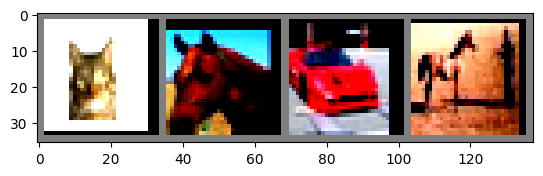

Labels: cat   horse car   horse


In [3]:
# Helper function to unnormalize and display images
def imshow(img):
    img = img / 2 + 0.5     # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Display 4 sample images
imshow(torchvision.utils.make_grid(images[:4]))
print('Labels:', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        # Conv Layer 1 (Input: 3 channels -> Output: 32 filters)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv Layer 2 (Input: 32 -> Output: 64)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Conv Layer 3 (Input: 64 -> Output: 128)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Conv Layer 4 (Input: 128 -> Output: 256)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Max Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Head
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, 10) # 10 classes in CIFAR-10

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # Output size: 16x16
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # Output size: 8x8
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x)))) # Output size: 4x4

        # Flatten
        x = x.view(-1, 256 * 4 * 4)

        # Fully Connected Layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN().to(device)

print("Model successfully loaded onto:", device)

Model successfully loaded onto: cuda


In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 20
print("Starting Training Loop...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100.0 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}%")

print("\nTraining Finished Successfully!")

Starting Training Loop...

Epoch [1/20] -> Loss: 1.5455 | Train Acc: 43.40%
Epoch [2/20] -> Loss: 1.1528 | Train Acc: 58.75%
Epoch [3/20] -> Loss: 0.9958 | Train Acc: 65.21%
Epoch [4/20] -> Loss: 0.9001 | Train Acc: 68.60%
Epoch [5/20] -> Loss: 0.8222 | Train Acc: 71.50%
Epoch [6/20] -> Loss: 0.7638 | Train Acc: 73.75%
Epoch [7/20] -> Loss: 0.7221 | Train Acc: 75.22%
Epoch [8/20] -> Loss: 0.6805 | Train Acc: 76.81%
Epoch [9/20] -> Loss: 0.6507 | Train Acc: 77.78%
Epoch [10/20] -> Loss: 0.6135 | Train Acc: 79.06%
Epoch [11/20] -> Loss: 0.5923 | Train Acc: 79.75%
Epoch [12/20] -> Loss: 0.5604 | Train Acc: 80.94%
Epoch [13/20] -> Loss: 0.5460 | Train Acc: 81.42%
Epoch [14/20] -> Loss: 0.5203 | Train Acc: 82.35%
Epoch [15/20] -> Loss: 0.5035 | Train Acc: 82.97%
Epoch [16/20] -> Loss: 0.4879 | Train Acc: 83.25%
Epoch [17/20] -> Loss: 0.4699 | Train Acc: 84.09%
Epoch [18/20] -> Loss: 0.4570 | Train Acc: 84.46%
Epoch [19/20] -> Loss: 0.4470 | Train Acc: 84.79%
Epoch [20/20] -> Loss: 0.4320 | 

Evaluating Model on Test Dataset...

Final Test Accuracy: 84.14%
 Success! You have comfortably crossed the 80% target requested by your professor.

Visualizing learned filters from the first convolutional layer...


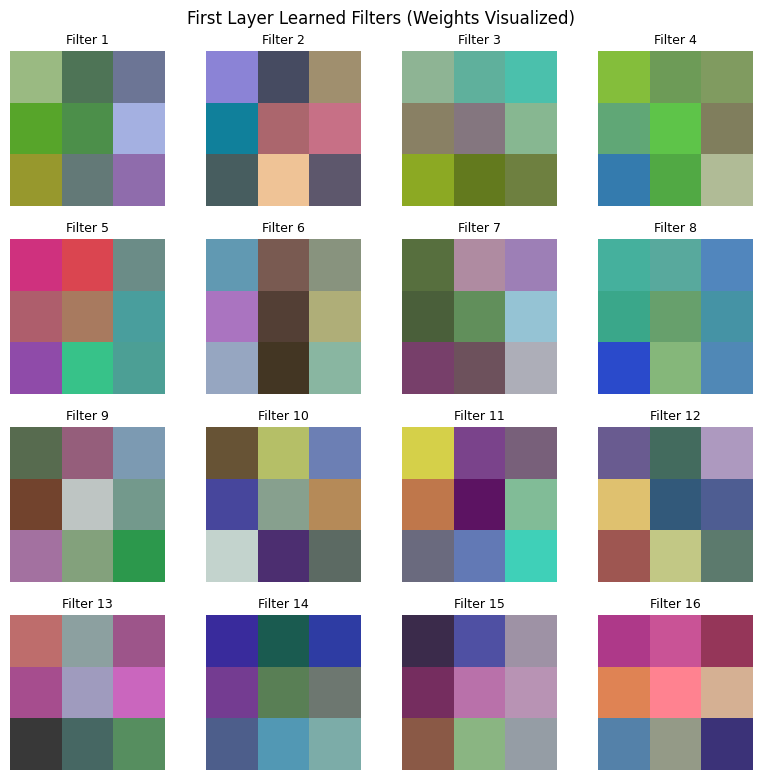

In [12]:
# STEP 4: TEST ACCURACY EVALUATION (Target >= 80%)
print("Evaluating Model on Test Dataset...")
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

final_test_acc = 100.0 * test_correct / test_total
print(f"\nFinal Test Accuracy: {final_test_acc:.2f}%")

if final_test_acc >= 80.0:
    print(" Success! You have comfortably crossed the 80% target requested by your professor.")
else:
    print(" The test accuracy is slightly below 80%. We might need a few more epochs.")


# STEP 5: VISUALIZE LEARNED FILTERS FROM THE FIRST LAYER
print("\nVisualizing learned filters from the first convolutional layer...")

# Extract weights from conv1 layer
filters = model.conv1.weight.data.cpu().numpy()

# Normalize filter values to [0, 1] for crisp plotting
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Plot the first 16 filters out of 32
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("First Layer Learned Filters (Weights Visualized)", fontsize=12, y=0.97)

for i, ax in enumerate(axes.flat):
    if i < 16:
        # Transpose from (Channels, Height, Width) to (Height, Width, Channels) for matplotlib
        filter_img = np.transpose(filters[i], (1, 2, 0))
        ax.imshow(filter_img)
        ax.axis('off')
        ax.set_title(f"Filter {i+1}", fontsize=9)

plt.tight_layout()
plt.show()